### Denoising Autoencoder on MNIST


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

np.random.seed(42)
tf.random.set_seed(42)

C:\Users\Shivansh\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\Shivansh\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\Shivansh\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\Shivansh\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print('train shape:', x_train.shape)
print('test shape:', x_test.shape)

train shape: (60000, 28, 28, 1)
test shape: (10000, 28, 28, 1)


In [3]:
def add_noise(images, noise_factor=0.5):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = np.clip(noisy, 0.0, 1.0)
    return noisy

noise_factor = 0.5
x_train_noisy = add_noise(x_train, noise_factor)
x_test_noisy = add_noise(x_test, noise_factor)

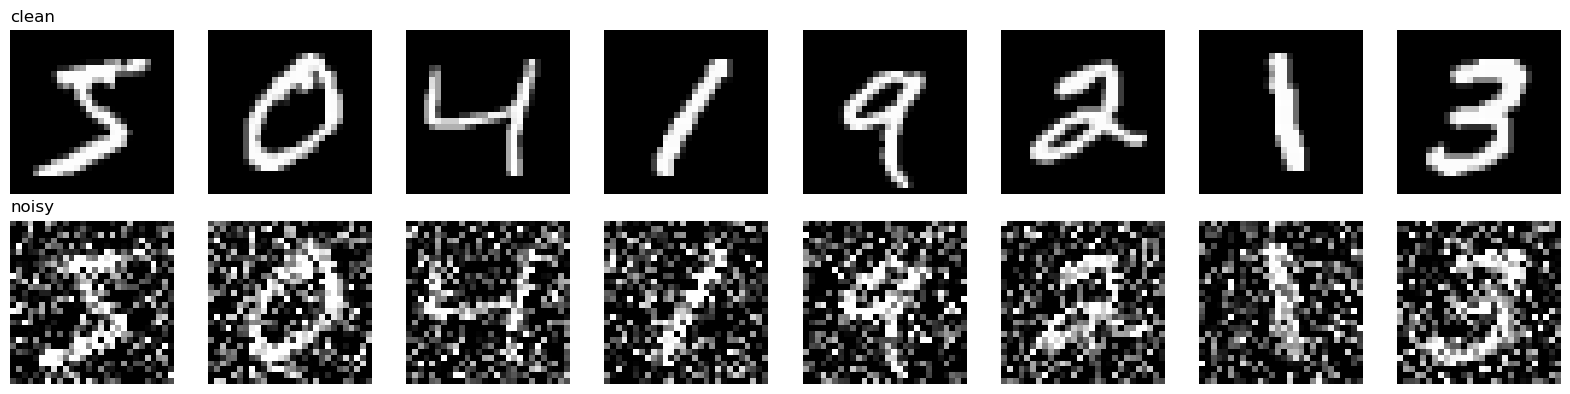

In [4]:
n = 8
plt.figure(figsize=(16, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title('clean', loc='left')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title('noisy', loc='left')

plt.tight_layout()
plt.show()

In [5]:
input_img = layers.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 16)            │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - loss: 0.2649 - val_loss: 0.1212
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - loss: 0.1198 - val_loss: 0.1119
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.1123 - val_loss: 0.1084
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.1090 - val_loss: 0.1063
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - loss: 0.1070 - val_loss: 0.1048
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.1055 - val_loss: 0.1036
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - loss: 0.1042 - val_loss: 0.1023
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.1032 - val_loss: 0.1014
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - loss: 0.1023 - val_loss: 0.1007
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.1016 - val_loss: 0.1001
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - loss: 0.1011 - val_loss: 0.0997
Epoch 12/20
469/469 ━━━━━━━━━━

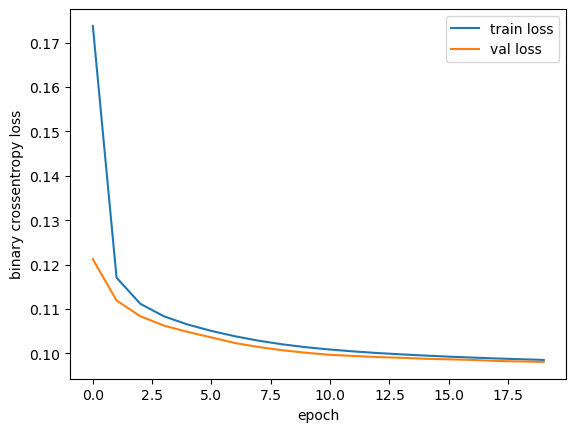

In [7]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('binary crossentropy loss')
plt.legend()
plt.show()

In [8]:
denoised_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


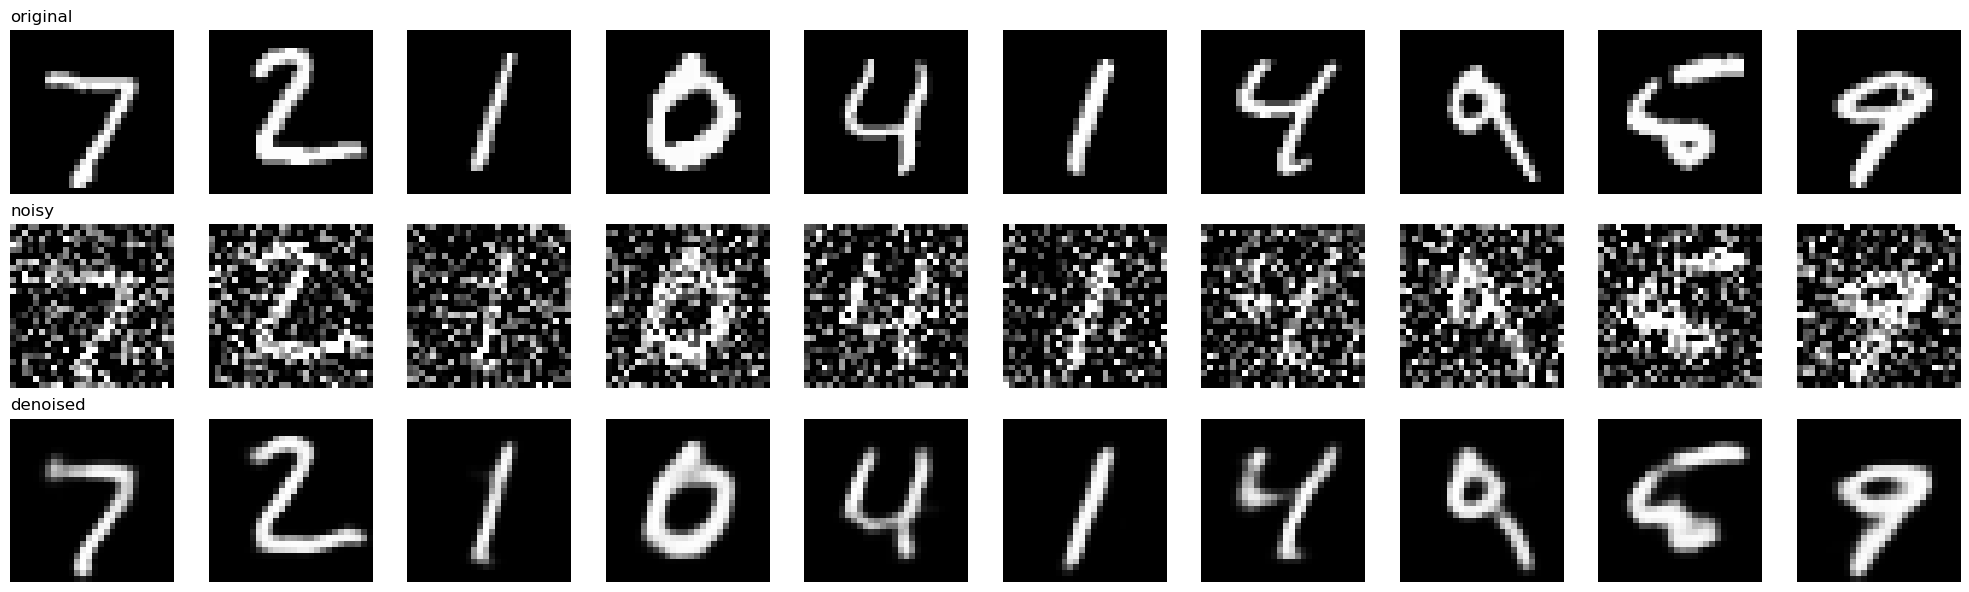

In [9]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title('original', loc='left')

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title('noisy', loc='left')

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title('denoised', loc='left')

plt.tight_layout()
plt.show()

In [10]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnr_noisy = np.mean([psnr(x_test[i], x_test_noisy[i], data_range=1.0) for i in range(len(x_test))])
psnr_denoised = np.mean([psnr(x_test[i], denoised_images[i], data_range=1.0) for i in range(len(x_test))])

ssim_noisy = np.mean([ssim(x_test[i].squeeze(), x_test_noisy[i].squeeze(), data_range=1.0) for i in range(len(x_test))])
ssim_denoised = np.mean([ssim(x_test[i].squeeze(), denoised_images[i].squeeze(), data_range=1.0) for i in range(len(x_test))])

print(f'PSNR noisy vs clean:    {psnr_noisy:.2f} dB')
print(f'PSNR denoised vs clean: {psnr_denoised:.2f} dB')
print(f'SSIM noisy vs clean:    {ssim_noisy:.4f}')
print(f'SSIM denoised vs clean: {ssim_denoised:.4f}')

PSNR noisy vs clean:    9.39 dB
PSNR denoised vs clean: 19.69 dB
SSIM noisy vs clean:    0.3752
SSIM denoised vs clean: 0.8634


In [11]:
noise_levels = [0.2, 0.4, 0.6, 0.8, 1.0]
results = {}

for nf in noise_levels:
    xt_noisy = add_noise(x_test, nf)
    preds = autoencoder.predict(xt_noisy, verbose=0)
    score = np.mean([psnr(x_test[i], preds[i], data_range=1.0) for i in range(len(x_test))])
    results[nf] = score
    print(f'noise factor {nf} -> avg PSNR {score:.2f} dB')

noise factor 0.2 -> avg PSNR 22.69 dB
noise factor 0.4 -> avg PSNR 20.90 dB
noise factor 0.6 -> avg PSNR 18.33 dB
noise factor 0.8 -> avg PSNR 15.76 dB
noise factor 1.0 -> avg PSNR 13.86 dB


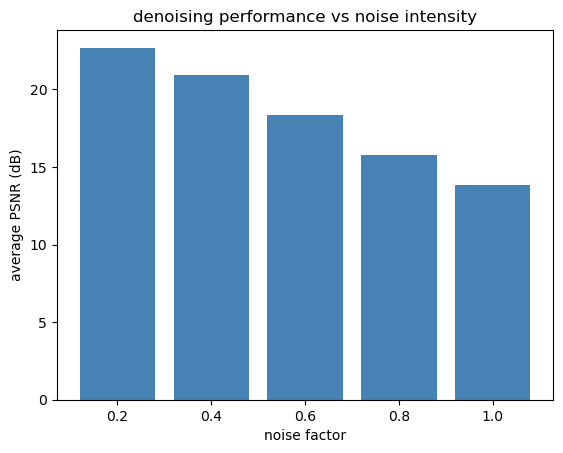

In [12]:
plt.bar([str(k) for k in results.keys()], list(results.values()), color='steelblue')
plt.xlabel('noise factor')
plt.ylabel('average PSNR (dB)')
plt.title('denoising performance vs noise intensity')
plt.show()

### Analysis

The autoencoder learns to remove a good amount of the Gaussian noise while keeping the overall stroke shape of each digit intact, which is the main goal here. A few things stood out while working through this:

- The reconstructed digits are slightly blurrier than the originals. This is a known side effect of the pixel-wise loss (binary crossentropy / MSE-style objectives push the model towards an average-looking reconstruction rather than sharp edges).
- The PSNR and SSIM scores both improve substantially after denoising compared to the raw noisy images, which lines up with what the visual grid shows - the digits go from looking grainy and partially obscured to clearly readable.
- Performance drops off as the noise factor increases beyond what the model was trained on (0.5). At very high noise levels (0.8-1.0) some digits become genuinely ambiguous even to a human eye, and the model's reconstructions degrade accordingly. Training on a mix of noise levels would likely make the model more robust here.
- A couple of digit pairs that are visually similar when corrupted (4/9, 3/8) occasionally get reconstructed with slightly the wrong shape, suggesting the bottleneck is compressing away some fine detail needed to disambiguate them.
- The architecture used here is intentionally small (two conv blocks in the encoder/decoder). A deeper network or one with skip connections (closer to a U-Net) would likely preserve sharper detail, at the cost of more parameters and training time.

Overall the model does what it's meant to do: it strips out random noise and recovers a clean, recognizable digit, with the main limitation being a loss of fine sharpness rather than loss of digit identity.